In [7]:
import numpy as np
import xarray as xr
import numpy as np

In [8]:
stim_ds = xr.load_dataset("stim_segmented_traces (1).nc")

In [9]:
iti_ds = xr.load_dataset("stim_segmented_greys.nc")

In [10]:
spine_id_stim = stim_ds["ids"].values

stim_ds = stim_ds.rename({"ids": "time"})
stim_ds = stim_ds.assign_coords(spine_id=("trial", spine_id_stim))
if "ids" in stim_ds.coords:
    stim_ds = stim_ds.drop_vars("ids")
print(stim_ds)
print("coords:", list(stim_ds.coords))

<xarray.Dataset> Size: 177MB
Dimensions:     (trial: 1917, stim_index: 96, time: 120)
Coordinates:
  * trial       (trial) int64 15kB 0 1 2 3 4 5 ... 1911 1912 1913 1914 1915 1916
    spine_id    (trial) float64 15kB 1.0 2.0 3.0 4.0 5.0 ... nan 549.0 550.0 nan
  * stim_index  (stim_index) int64 768B 0 1 2 3 4 5 6 7 ... 89 90 91 92 93 94 95
    stim        (stim_index) int64 768B 150 60 300 180 210 ... 90 60 270 0 300
    time        (trial) float64 15kB 1.0 2.0 3.0 4.0 5.0 ... nan 549.0 550.0 nan
Data variables:
    trace       (trial, stim_index, time) float64 177MB -0.4162 ... 0.6211
Attributes:
    description:  Stimulus-segmented traces
coords: ['time', 'trial', 'stim_index', 'stim', 'spine_id']


In [11]:
spine_ids_iti = iti_ds["ids"].values
iti_ds = iti_ds.rename({"ids": "time"})
iti_ds = iti_ds.assign_coords(spine_id=("trial", spine_ids_iti))
if "ids" in iti_ds.coords:
    iti_ds = iti_ds.drop_vars("ids")
print(iti_ds)

<xarray.Dataset> Size: 75MB
Dimensions:     (trial: 1917, stim_index: 96, time: 51)
Coordinates:
  * trial       (trial) int64 15kB 0 1 2 3 4 5 ... 1911 1912 1913 1914 1915 1916
    spine_id    (trial) float64 15kB 1.0 2.0 3.0 4.0 5.0 ... nan 549.0 550.0 nan
  * stim_index  (stim_index) int64 768B 0 1 2 3 4 5 6 7 ... 89 90 91 92 93 94 95
    stim        (stim_index) int64 768B 150 60 300 180 210 ... 90 60 270 0 300
    time        (trial) float64 15kB 1.0 2.0 3.0 4.0 5.0 ... nan 549.0 550.0 nan
Data variables:
    trace       (trial, stim_index, time) float64 75MB -0.1006 ... 0.1044
Attributes:
    description:  Stimulus-segmented traces


In [12]:
# assert dfs look like how we want them to and find unique angles

if "ids" in stim_ds.dims:
    stim_ds = stim_ds.rename({"ids": "time"})
if "ids" in iti_ds.dims:
    iti_ds = iti_ds.rename({"ids": "time"})

assert "spine_id" in stim_ds.coords, list(stim_ds.coords)
assert "spine_id" in iti_ds.coords, list(iti_ds.coords)

assert stim_ds["trace"].dims == ("trial", "stim_index", "time")
assert iti_ds["trace"].dims  == ("trial", "stim_index", "time")
assert stim_ds.sizes["trial"] == iti_ds.sizes["trial"]
assert stim_ds.sizes["stim_index"] == iti_ds.sizes["stim_index"]

angles = stim_ds["stim"].values
unique_angles = np.sort(np.unique(angles))
print("unique angles:", unique_angles, "n=", len(unique_angles))

unique angles: [  0  30  60  90 120 150 180 210 240 270 300 330] n= 12


In [13]:
#align trials

spine_id_coord = "spine_id"  
trace_var = "trace"

def add_row_key(ds):
    if "trial" in ds.coords:
        trial_vals = ds["trial"].values
    else:
        trial_vals = np.arange(ds.sizes["trial"])

    spine_vals = ds[spine_id_coord].values

    keys = np.array([
        f"{int(s)}|{t}" if not np.isnan(s) else f"nan|{t}"
        for s, t in zip(spine_vals, trial_vals)
    ], dtype=object)

    return ds.assign_coords(row_key=("trial", keys))

stim_k = add_row_key(stim_ds)
iti_k  = add_row_key(iti_ds)

common = np.intersect1d(stim_k["row_key"].values, iti_k["row_key"].values)
print("Common rows:", len(common), "of stim:", stim_k.sizes["trial"], "iti:", iti_k.sizes["trial"])

stim_aligned = stim_k.sel(trial=stim_k["row_key"].isin(common)).sortby("row_key")
iti_aligned  = iti_k.sel(trial=iti_k["row_key"].isin(common)).sortby("row_key")

assert np.array_equal(stim_aligned["row_key"].values, iti_aligned["row_key"].values)
print("Aligned OK. New n_rows:", stim_aligned.sizes["trial"])

Common rows: 1917 of stim: 1917 iti: 1917
Aligned OK. New n_rows: 1917


Chance: 0.08333333333333333
Dropping NaN spine_id rows: 162
Unique spines: 544 kept: 294
Accuracy: 0.9145833333333333
Balanced accuracy: 0.9145833333333333


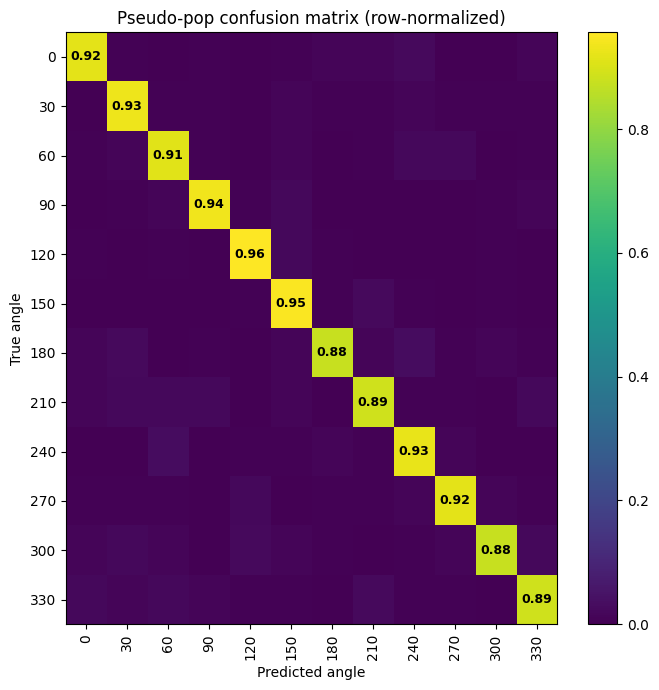

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

#settings
stim_angle_coord = "stim"
stim_win = slice(10, 60)
iti_win  = slice(0, 50)

min_repeats_per_spine = 3
n_draws = 100
rng_seed = 0

# responses
stim_resp = stim_aligned[trace_var].isel(time=stim_win).mean("time")  # (trial, stim_index)
iti_base  = iti_aligned[trace_var].isel(time=iti_win).mean("time")    # (trial, stim_index)
resp = stim_resp - iti_base

resp_values = resp.values
angles_by_si = stim_aligned[stim_angle_coord].values
unique_angles = np.sort(np.unique(angles_by_si))
print("Chance:", 1/len(unique_angles))

# spine ids (rows)
spine_ids = stim_aligned[spine_id_coord].values
nan_mask = np.isnan(spine_ids)
valid_rows = np.where(~nan_mask)[0]
if nan_mask.any():
    print("Dropping NaN spine_id rows:", nan_mask.sum())

# spine -> rows map
sp_to_rows = {}
for r in valid_rows:
    sid = spine_ids[r]
    sp_to_rows.setdefault(sid, []).append(r)

all_spines = np.array(sorted(sp_to_rows.keys()))
keep_spines = np.array([sid for sid in all_spines if len(sp_to_rows[sid]) >= min_repeats_per_spine])
print("Unique spines:", len(all_spines), "kept:", len(keep_spines))

rng = np.random.default_rng(rng_seed)

def make_draw(resp_values, spines, sp_to_rows, rng):
    chosen_rows = np.array([rng.choice(sp_to_rows[sid]) for sid in spines])  # (n_spines,)
    R = resp_values[chosen_rows, :]  # (n_spines, n_stim_index)
    X_draw = R.T                     # (n_stim_index, n_spines)
    return X_draw

n_stim = resp_values.shape[1]
X_draws = np.zeros((n_draws, n_stim, len(keep_spines)), dtype=np.float64)
for d in range(n_draws):
    X_draws[d] = make_draw(resp_values, keep_spines, sp_to_rows, rng)

# draw-level split
draw_ids = np.arange(n_draws)
train_draws, test_draws = train_test_split(draw_ids, test_size=0.2, random_state=0)

X_train = X_draws[train_draws].reshape(-1, X_draws.shape[-1])
X_test  = X_draws[test_draws].reshape(-1, X_draws.shape[-1])

y_train = np.tile(angles_by_si, len(train_draws))
y_test  = np.tile(angles_by_si, len(test_draws))

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=5000, class_weight="balanced")
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
acc = (y_pred == y_test).mean()
bacc = balanced_accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Balanced accuracy:", bacc)

# confusion matrix
labels = unique_angles
cm = confusion_matrix(y_test, y_pred, labels=labels)
cmn = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7,7))
plt.imshow(cmn, aspect="auto")
plt.colorbar()
plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)
plt.xlabel("Predicted angle")
plt.ylabel("True angle")
plt.title("Pseudo-pop confusion matrix (row-normalized)")
per_angle_acc = np.diag(cmn)

for i, acc_i in enumerate(per_angle_acc):
    plt.text(i, i, f"{acc_i:.2f}",
             ha="center", va="center",
             color="white" if acc_i < 0.5 else "black",
             fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
import numpy as np

rng_shuf = np.random.default_rng(123)
y_train_shuf = rng_shuf.permutation(y_train)

clf_shuf = LogisticRegression(max_iter=5000, class_weight="balanced")
clf_shuf.fit(X_train_s, y_train_shuf)

y_pred_shuf = clf_shuf.predict(X_test_s)
acc_shuf = (y_pred_shuf == y_test).mean()
bacc_shuf = balanced_accuracy_score(y_test, y_pred_shuf)

print("Shuffled-label accuracy:", acc_shuf)
print("Shuffled-label balanced accuracy:", bacc_shuf)
print("Chance:", 1/len(np.unique(y_test)))

Shuffled-label accuracy: 0.08177083333333333
Shuffled-label balanced accuracy: 0.08177083333333335
Chance: 0.08333333333333333


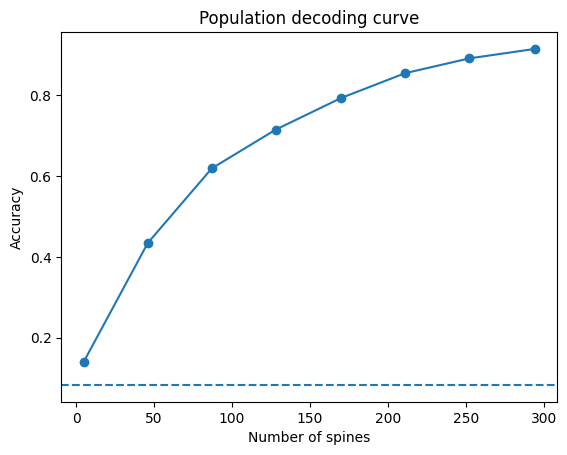

In [16]:
def population_curve(resp_values, keep_spines, sp_to_rows, angles_by_si,
                     n_draws=200, max_spines=None):

    if max_spines is None:
        max_spines = len(keep_spines)

    rng = np.random.default_rng(0)
    results = []

    spine_counts = np.linspace(5, max_spines, 8, dtype=int)

    for n_sp in spine_counts:
        sp_subset = rng.choice(keep_spines, size=n_sp, replace=False)

        X_draws = np.zeros((n_draws, resp_values.shape[1], n_sp))
        for d in range(n_draws):
            chosen_rows = np.array([rng.choice(sp_to_rows[s]) for s in sp_subset])
            R = resp_values[chosen_rows, :]
            X_draws[d] = R.T

        draw_ids = np.arange(n_draws)
        train_d, test_d = train_test_split(draw_ids, test_size=0.2, random_state=0)

        X_train = X_draws[train_d].reshape(-1, n_sp)
        X_test  = X_draws[test_d].reshape(-1, n_sp)

        y_train = np.tile(angles_by_si, len(train_d))
        y_test  = np.tile(angles_by_si, len(test_d))

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf = LogisticRegression(max_iter=3000, class_weight="balanced")
        clf.fit(X_train, y_train)

        acc = clf.score(X_test, y_test)
        results.append(acc)

    return spine_counts, results

counts, accs = population_curve(resp_values, keep_spines, sp_to_rows, angles_by_si)

plt.figure()
plt.plot(counts, accs, marker='o')
plt.axhline(1/len(unique_angles), linestyle='--')
plt.xlabel("Number of spines")
plt.ylabel("Accuracy")
plt.title("Population decoding curve")
plt.show()

OSI median: 0.39085244547181186


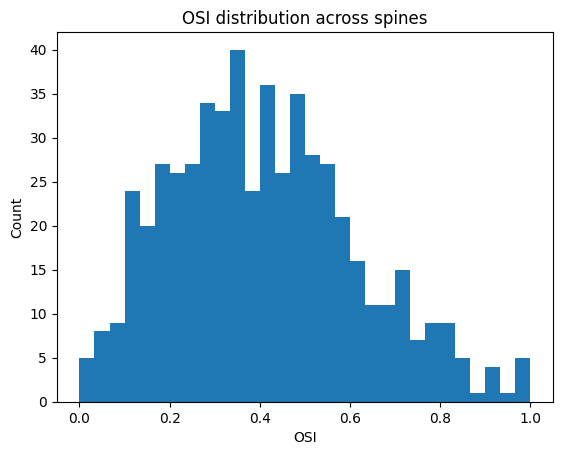

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1) baseline-subtracted scalar response per row × stim_index
stim_win = slice(10, 60)
iti_win  = slice(0, 40)

stim_resp = stim_ds["trace"].isel(time=stim_win).mean("time")
iti_base  = iti_ds["trace"].isel(time=iti_win).mean("time")
resp = stim_resp - iti_base  # (trial_row, stim_index)

# 2) mean across rows per spine_id -> (spine_id, stim_index)
resp_spine_si = resp.groupby(stim_ds["spine_id"]).mean("trial")

# 3) angle tuning per spine -> (spine_id, stim)
tuning = resp_spine_si.groupby(stim_ds["stim"]).mean("stim_index")

angles = tuning["stim"].values
theta = np.deg2rad(angles)

R = tuning.values  # (n_spines, n_angles)
R = np.maximum(R, 0)  # optional: if baseline subtraction yields negatives

x = (R * np.cos(2*theta)).sum(axis=1)
y = (R * np.sin(2*theta)).sum(axis=1)
magnitude = np.sqrt(x**2 + y**2)
OSI = magnitude / (R.sum(axis=1) + 1e-9)
pref_ori_deg = (np.rad2deg(np.arctan2(y, x) / 2.0) % 180)

print("OSI median:", np.nanmedian(OSI))

plt.figure()
plt.hist(OSI, bins=30)
plt.xlabel("OSI")
plt.ylabel("Count")
plt.title("OSI distribution across spines")
plt.show()